In [4]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
import matplotlib 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 
import plotly.express as px


print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [3]:
df = pd.read_csv(r"C:\Users\malum\Desktop\faculdade\learning_machine\dados\creditcard.csv")
print(f"Dataset carregado! Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")


Dataset carregado! Linhas: 284807 | Colunas: 31


In [5]:
total_nulos = df.isnull().sum().sum()
print(f"Total de valores nulos no dataset: {total_nulos}")

Total de valores nulos no dataset: 0


In [6]:
contagem_classes = df['Class'].value_counts().reset_index()
contagem_classes.columns = ['Classe', 'Total']
contagem_classes['Classe'] = contagem_classes['Classe'].map({0: 'Normal (Legítima)', 1: 'Fraude'})

fig_barras = px.bar(
    contagem_classes, 
    x='Classe', 
    y='Total',
    text='Total',
    title='O Desafio do Desbalanceamento Absoluto de Dados',
    labels={'Total': 'Número de Transações (Escala Log)', 'Classe': 'Tipo de Transação'},
    color='Classe',
    color_discrete_map={'Normal (Legítima)': '#2ecc71', 'Fraude': '#e74c3c'} 
)
fig_barras.update_traces(textposition='outside')
fig_barras.update_layout(height=500, template='plotly_dark', yaxis_type="log")
fig_barras.show()

In [7]:
class_0 = df.loc[df['Class'] == 0]["Time"]
class_1 = df.loc[df['Class'] == 1]["Time"]

fig_densidade = ff.create_distplot([class_0, class_1], ['Legítima', 'Fraude'], show_hist=False, show_rug=False)
fig_densidade['layout'].update(
    title='Gráfico de Densidade: Tempo das Transações de Cartão de Crédito', 
    xaxis=dict(title='Tempo decorrido (em segundos)'),
    yaxis=dict(title='Densidade')
)
fig_densidade.show()


In [8]:
df['Hora'] = df['Time'].apply(lambda x: np.floor(x / 3600))

dataf = df.groupby(['Hora', 'Class'])['Amount'].aggregate(['sum', 'count', 'mean']).reset_index()
dataf.columns = ['Hora', 'Classe', 'Soma_Total', 'Total_Transacoes', 'Media_Valor']

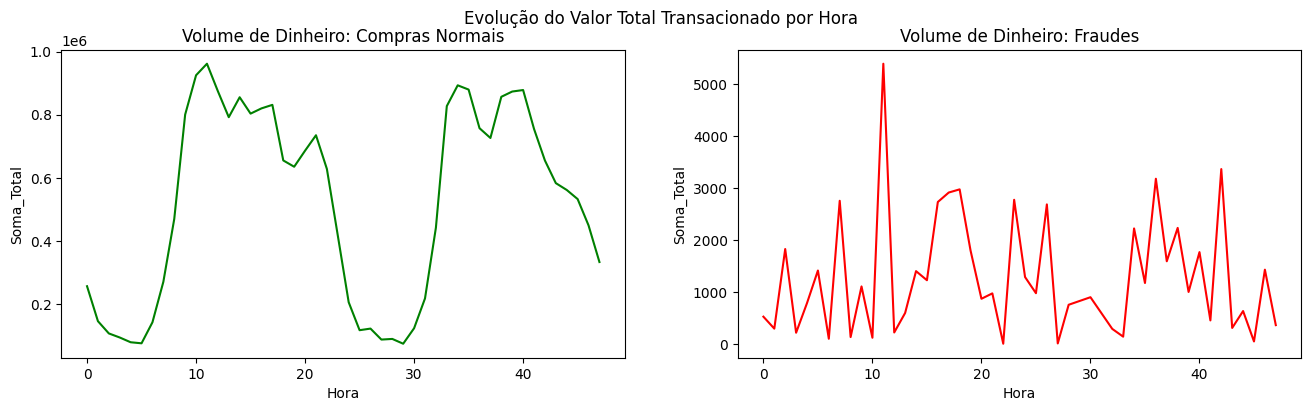

In [9]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(16,4))
sns.lineplot(ax=ax1, x="Hora", y="Soma_Total", data=dataf.loc[dataf.Classe==0], color="green")
ax1.set_title("Volume de Dinheiro: Compras Normais")
sns.lineplot(ax=ax2, x="Hora", y="Soma_Total", data=dataf.loc[dataf.Classe==1], color="red")
ax2.set_title("Volume de Dinheiro: Fraudes")
plt.suptitle("Evolução do Valor Total Transacionado por Hora")
plt.show()

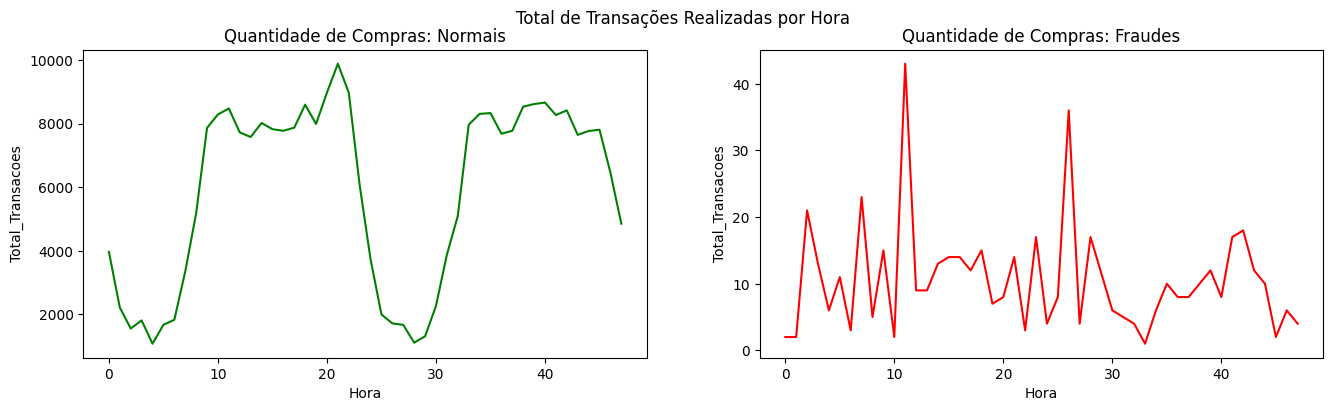

In [10]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(16,4))
sns.lineplot(ax=ax1, x="Hora", y="Total_Transacoes", data=dataf.loc[dataf.Classe==0], color="green")
ax1.set_title("Quantidade de Compras: Normais")
sns.lineplot(ax=ax2, x="Hora", y="Total_Transacoes", data=dataf.loc[dataf.Classe==1], color="red")
ax2.set_title("Quantidade de Compras: Fraudes")
plt.suptitle("Total de Transações Realizadas por Hora")
plt.show()

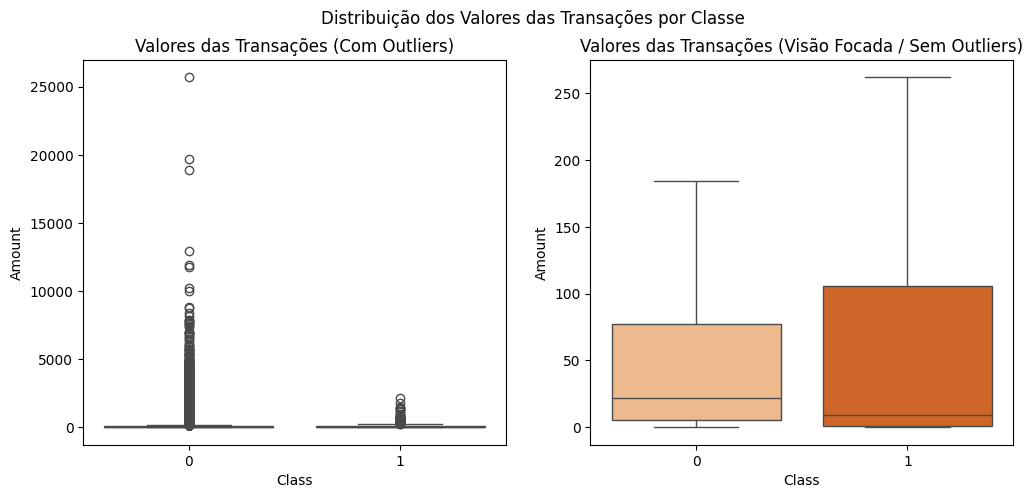

In [13]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))
sns.boxplot(ax=ax1, x="Class", y="Amount", hue="Class", data=df, palette="Oranges", legend=False, showfliers=True)
ax1.set_title("Valores das Transações (Com Outliers)")
sns.boxplot(ax=ax2, x="Class", y="Amount", hue="Class", data=df, palette="Oranges", legend=False, showfliers=False)
ax2.set_title("Valores das Transações (Visão Focada / Sem Outliers)")
plt.suptitle("Distribuição dos Valores das Transações por Classe")
plt.show()